In [2]:
import pandas as pd
df = pd.read_csv('train.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [4]:
#remove label columns apart from toxic
df = df.drop( columns = ['severe_toxic','obscene','threat','insult','identity_hate'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            159571 non-null  str  
 1   comment_text  159571 non-null  str  
 2   toxic         159571 non-null  int64
dtypes: int64(1), str(2)
memory usage: 3.7 MB


In [5]:
!pip install contractions

Defaulting to user installation because normal site-packages is not writeable

   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ------------------------------ --------- 3/4 [contractions]
   ---------------------------------------- 4/4 [contractions]




[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
#basic text cleaning

import re
import contractions

def clean_text(text):

    text = text.lower()                        #lowercase
    text = contractions.fix(text)              #contraction expansion
    text = re.sub(r'[^a-z]', ' ', text)        #replace non-alphabet with space
    text = re.sub(r'\s+', ' ', text).strip()   #remove extra space

    return text

#apply to new column
df['clean_text'] = df['comment_text'].apply(clean_text)

#remove empty rowes after cleaning
df = df[df['clean_text'] != ""]

In [25]:
#drop duplications

df = df.drop_duplicates( subset = ['clean_text'] )

In [26]:
#info about data after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 158230 entries, 0 to 159570
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            158230 non-null  str  
 1   comment_text  158230 non-null  str  
 2   toxic         158230 non-null  int64
 3   clean_text    158230 non-null  str  
dtypes: int64(1), str(3)
memory usage: 6.0 MB


In [27]:
#label distribution
df['toxic'].value_counts()

toxic
0    143073
1     15157
Name: count, dtype: int64

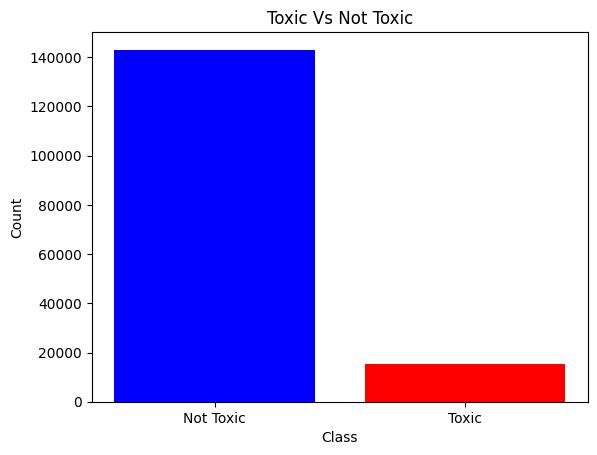

In [28]:
#bar graph for label distribution

import matplotlib.pyplot as plt

plt.bar(['Not Toxic','Toxic'] , df['toxic'].value_counts(), color = ['blue', 'red'])
plt.title('Toxic Vs Not Toxic')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [30]:
#generate clean data set file
df.to_csv('clean_data.csv', index = False )